<a href="https://colab.research.google.com/github/kormladorwu/MyPortfolio/blob/main/Spam_Detection_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing libraries
import pandas as pd
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


In [ ]:
## Mounts Google Drive


from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:


# read the spam_sms.csv file from Google Drive into a pandas DataFrame and displays the first five rows
df = pd.read_csv('/content/drive/My Drive/spam_sms.csv')

df.head()


,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# download essential NLTK resources:

# "stopwords" – for removing common irrelevant words

# "punkt" – for tokenizing text into words or sentences

# "wordnet" – for lemmatization (reducing words to their root form)

# "punkt_tab" – additional tokenizer data for better text processing


nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download("punkt_tab")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Remove stopwords and lemmatize words in the text

# Clean, tokenize, and preprocess the 'v2' column to create 'cleaned_text'


stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\W", " ", text)
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]
    return " ".join(tokens)

df['cleaned_text'] = df['v2'].astype(str).apply(clean_text)

In [ ]:
# Encode labels: 'ham' as 0 and 'spam' as 1

# Split data into training (80%) and temporary (20%) sets


from sklearn.model_selection import train_test_split

df['label_encoded'] = df['v1'].map({'ham': 0, 'spam': 1})

X_train, X_temp, y_train, y_temp = train_test_split(df['cleaned_text'], df['label_encoded'], test_size=0.2, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
# Vectorize the text data using TF-IDF, keeping the top 5000 features.
# Fit on the training set and transform all splits into numerical feature matrices.
# This representation is suitable for feeding into machine learning models.

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
# Train a Multinomial Naive Bayes classifier using the TF-IDF vectorized training data.
# Predict on the test set and evaluate performance using a classification report.

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)
y_pred_nb = nb_model.predict(X_test_vec)

print("Naive Bayes Results:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Results:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       492
           1       1.00      0.82      0.90        66

    accuracy                           0.98       558
   macro avg       0.99      0.91      0.94       558
weighted avg       0.98      0.98      0.98       558



In [ ]:
#viewing the ROC value
from sklearn.metrics import roc_auc_score

y_pred_proba_nb = nb_model.predict_proba(X_test_vec)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_proba_nb)
print(f"AUC-ROC: {auc_score:.3f}")


AUC-ROC: 0.967


In [ ]:
# Train a Support Vector Machine (SVM) classifier using TF-IDF features.
# Predict on the test set and print a classification report to evaluate performance.


from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_vec, y_train)
y_pred_svm = svm_model.predict(X_test_vec)

print("SVM Results:")
print(classification_report(y_test, y_pred_svm))


SVM Results:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       492
           1       0.92      0.86      0.89        66

    accuracy                           0.97       558
   macro avg       0.95      0.93      0.94       558
weighted avg       0.97      0.97      0.97       558



In [ ]:
#AUC ROC for SVM
from sklearn.metrics import roc_auc_score

# Get decision scores instead of probabilities
y_scores_svm = svm_model.decision_function(X_test_vec)

# Calculate AUC-ROC
auc_svm = roc_auc_score(y_test, y_scores_svm)
print(f"AUC-ROC: {auc_svm:.3f}")


AUC-ROC: 0.981


In [ ]:
# Train a Logistic Regression classifier using TF-IDF features.
# Predict on the test set and print a classification report to evaluate performance.


from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_vec, y_train)

y_pred_lr = lr_model.predict(X_test_vec)

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       492
           1       0.92      0.71      0.80        66

    accuracy                           0.96       558
   macro avg       0.94      0.85      0.89       558
weighted avg       0.96      0.96      0.96       558



In [ ]:
#AUC LR
from sklearn.metrics import roc_auc_score

y_pred_proba_lr = lr_model.predict_proba(X_test_vec)[:, 1]
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
print(f"AUC-ROC: {auc_lr:.3f}")


AUC-ROC: 0.977


In [ ]:
# Import required libraries for building and training deep learning models (CNN and LSTM).
# Includes tools for text tokenization, sequence padding, and model evaluation.

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D, LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report

In [ ]:
#Tokenize and pad text data for deep learning models.
# Converts messages into sequences of word indices using a limited vocabulary (10,000 words).
# Pads all sequences to the same length (100 words) for consistent input shape.


# Parameters
vocab_size = 20000  # Size of vocabulary
max_len = 200       # Max words in a message
embedding_dim = 300 # Size of embedding vector

# Tokenize
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')


In [ ]:
# Load pre-trained GloVe word embeddings into a dictionary.
# Then create an embedding matrix where each row corresponds to a word in the tokenizer's vocabulary.
# Words not found in the GloVe index are represented by a row of zeros.
# This matrix will be used to initialize the embedding layer in the neural network.

# Download GloVe embeddings
!wget http://nlp.stanford.edu/data/glove.6B.zip -O glove.6B.zip
import os
if os.path.exists("glove.6B.zip") and os.path.getsize("glove.6B.zip") > 800000000: # Basic size check (GloVe 6B is ~822MB)
    !unzip -o glove.6B.zip
else:
    print("GloVe file download failed or is incomplete.")


embedding_index = {}
with open("glove.6B.300d.txt", encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coeff = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coeff

# Create embedding matrix
embedding_matrix = np.zeros((vocab_size, embedding_dim))
word_index = tokenizer.word_index

for word, i in word_index.items():
    if i < vocab_size and word in embedding_index:
        embedding_matrix[i] = embedding_index[word]

--2025-10-07 08:33:45--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-10-07 08:33:46--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-10-07 08:33:46--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
# Define and compile a Convolutional Neural Network (CNN) for spam detection.
# The model uses pre-trained GloVe embeddings (frozen), a Conv1D layer to capture local features,
# followed by pooling and dense layers for classification.
# Train the model on the padded training data and validate on the validation set.


cnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix],
              input_length=max_len, trainable=False),
    Conv1D(filters=256, kernel_size=3, activation='relu'),   # More filters + smaller kernel
    BatchNormalization(),
    Conv1D(filters=256, kernel_size=5, activation='relu'),   # Second Conv layer
    MaxPooling1D(pool_size=2),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),                           # Bigger dense layer
    Dropout(0.4),                                            # Slightly reduced dropout
    Dense(1, activation='sigmoid')
])


cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()

# Train
cnn_model.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val), epochs=5, batch_size=32)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,000,000 (22.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,000,000 (22.89 MB)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 76s 525ms/step - accuracy: 0.8749 - loss: 0.9315 - val_accuracy: 0.9641 - val_loss: 0.3554
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 85s 546ms/step - accuracy: 0.9853 - loss: 0.0474 - val_accuracy: 0.9695 - val_loss: 0.1455
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 531ms/step - accuracy: 0.9950 - loss: 0.0219 - val_accuracy: 0.9695 - val_loss: 0.0965
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 75s 532ms/step - accuracy: 0.9978 - loss: 0.0075 - val_accuracy: 0.9749 - val_loss: 0.0822
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 526ms/step - accuracy: 0.9922 - loss: 0.0283 - val_accuracy: 0.9641 - val_loss: 0.2124


In [ ]:
# Predict labels for the test data using the CNN model, convert probabilities to binary labels (0 or 1),
# and display the classification metrics such as precision, recall, F1-score, and accuracy.

y_pred_cnn = (cnn_model.predict(X_test_pad) > 0.5).astype("int32")
print("CNN Results:")
print(classification_report(y_test, y_pred_cnn))

18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step
CNN Results:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       492
           1       0.98      0.82      0.89        66

    accuracy                           0.98       558
   macro avg       0.98      0.91      0.94       558
weighted avg       0.98      0.98      0.98       558



In [ ]:
#ROC for CNN
from sklearn.metrics import roc_auc_score

# Get predicted probabilities (positive class = 1)
y_pred_proba_cnn = cnn_model.predict(X_test_pad)

# Calculate AUC-ROC
auc_cnn = roc_auc_score(y_test, y_pred_proba_cnn)
print(f"AUC-ROC: {auc_cnn:.3f}")


18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 194ms/step
AUC-ROC: 0.957


In [ ]:
# LSTM model using pre-trained GloVe embeddings for spam detection

lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix],
              input_length=max_len, trainable=False),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])



lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

# Train
lstm_model.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val), epochs=5, batch_size=32)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,000,000 (22.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,000,000 (22.89 MB)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 63s 425ms/step - accuracy: 0.8112 - loss: 0.6394 - val_accuracy: 0.8492 - val_loss: 0.4260
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 57s 406ms/step - accuracy: 0.8680 - loss: 0.3987 - val_accuracy: 0.8492 - val_loss: 0.4245
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 57s 404ms/step - accuracy: 0.8627 - loss: 0.4139 - val_accuracy: 0.8492 - val_loss: 0.4251
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 60s 425ms/step - accuracy: 0.8678 - loss: 0.3971 - val_accuracy: 0.8492 - val_loss: 0.4246
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 60s 427ms/step - accuracy: 0.8622 - loss: 0.4021 - val_accuracy: 0.8492 - val_loss: 0.4265


In [ ]:
# Predict labels for the test data using the LSTM model, convert probabilities to binary labels (0 or 1),
# and display the classification metrics including precision, recall, F1-score, and accuracy.


y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype("int32")
print("LSTM Results:")
print(classification_report(y_test, y_pred_lstm))


18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step
LSTM Results:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       492
           1       0.00      0.00      0.00        66

    accuracy                           0.88       558
   macro avg       0.44      0.50      0.47       558
weighted avg       0.78      0.88      0.83       558



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#ROC for LSTM

from sklearn.metrics import roc_auc_score

# Predict probabilities for the positive class
y_pred_proba_lstm = lstm_model.predict(X_test_pad)

# Calculate AUC-ROC
auc_lstm = roc_auc_score(y_test, y_pred_proba_lstm)
print(f"AUC-ROC: {auc_lstm:.3f}")


18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 185ms/step
AUC-ROC: 0.508


In [ ]:
# Build and train a Bidirectional LSTM model for spam detection

bilstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix],
              input_length=max_len, trainable=False),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])



bilstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
bilstm_model.summary()

# Train
bilstm_model.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val), epochs=5, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,000,000 (22.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,000,000 (22.89 MB)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 120s 833ms/step - accuracy: 0.9041 - loss: 0.2624 - val_accuracy: 0.9677 - val_loss: 0.0757
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 112s 805ms/step - accuracy: 0.9490 - loss: 0.1440 - val_accuracy: 0.9767 - val_loss: 0.0731
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 123s 880ms/step - accuracy: 0.9755 - loss: 0.0805 - val_accuracy: 0.9838 - val_loss: 0.0573
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 114s 818ms/step - accuracy: 0.9841 - loss: 0.0477 - val_accuracy: 0.9874 - val_loss: 0.0546
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 112s 798ms/step - accuracy: 0.9872 - loss: 0.0402 - val_accuracy: 0.9838 - val_loss: 0.0590


In [ ]:
# Evaluate the Bidirectional LSTM model's performance on the test set
# Generates classification metrics including precision, recall, F1, and accuracy


from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# NOTE: A Bidirectional LSTM model named 'bilstm_model' needs to be built and trained before running this cell.

# Predict probabilities and convert to binary output
y_pred_bilstm = (bilstm_model.predict(X_test_pad) > 0.5).astype("int32")

# Flatten predictions
y_pred_bilstm = y_pred_bilstm.flatten()

# Print classification report
print("Bidirectional LSTM Results:")
print(classification_report(y_test, y_pred_bilstm))

18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 241ms/step
Bidirectional LSTM Results:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       492
           1       0.95      0.88      0.91        66

    accuracy                           0.98       558
   macro avg       0.97      0.94      0.95       558
weighted avg       0.98      0.98      0.98       558



In [ ]:
#RoC for Bilstm

from sklearn.metrics import roc_auc_score

# Get predicted probabilities for the positive class
y_pred_proba_bilstm = bilstm_model.predict(X_test_pad)

# Calculate AUC-ROC
auc_bilstm = roc_auc_score(y_test, y_pred_proba_bilstm)
print(f"AUC-ROC: {auc_bilstm:.3f}")


18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 319ms/step
AUC-ROC: 0.964


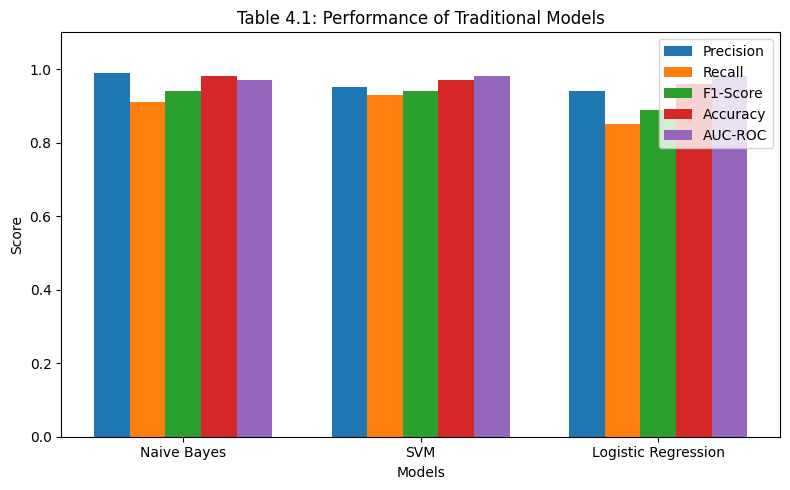

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ["Naive Bayes", "SVM", "Logistic Regression"]
precision = [0.99, 0.95, 0.94]
recall = [0.91, 0.93, 0.85]
f1_score = [0.94, 0.94, 0.89]
accuracy = [0.98, 0.97, 0.96]
auc_roc = [0.97, 0.98, 0.98]

# Set positions for each group of bars
x = np.arange(len(models))
width = 0.15  # width of each bar

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 5))

# Plot each metric
ax.bar(x - 2*width, precision, width, label="Precision")
ax.bar(x - width, recall, width, label="Recall")
ax.bar(x, f1_score, width, label="F1-Score")
ax.bar(x + width, accuracy, width, label="Accuracy")
ax.bar(x + 2*width, auc_roc, width, label="AUC-ROC")

# Add labels and formatting
ax.set_xlabel("Models")
ax.set_ylabel("Score")
ax.set_title("Table 4.1: Performance of Traditional Models")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.1)
ax.legend()

# Layout adjustment
plt.tight_layout()
plt.show()


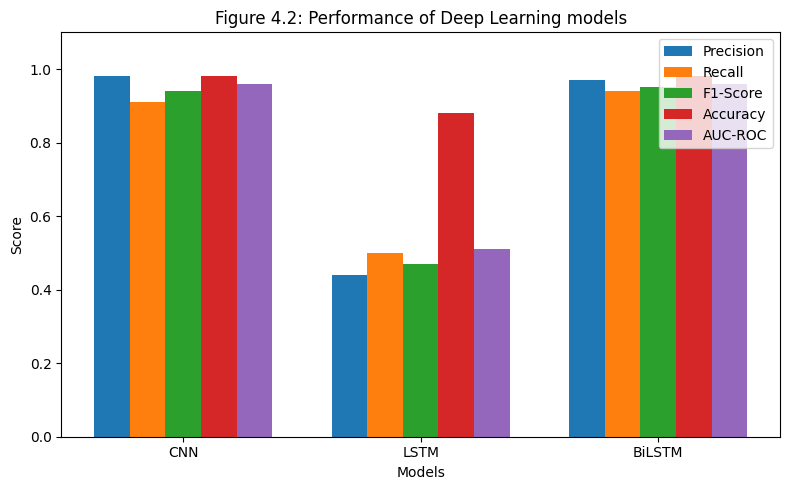

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ["CNN", "LSTM", "BiLSTM"]
precision = [0.98, 0.44, 0.97]
recall = [0.91, 0.50, 0.94]
f1_score = [0.94, 0.47, 0.95]
accuracy = [0.98, 0.88, 0.98]
auc_roc = [0.96, 0.51, 0.96]

# Set positions for each group of bars
x = np.arange(len(models))
width = 0.15  # width of each bar

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 5))

# Plot each metric
ax.bar(x - 2*width, precision, width, label="Precision")
ax.bar(x - width, recall, width, label="Recall")
ax.bar(x, f1_score, width, label="F1-Score")
ax.bar(x + width, accuracy, width, label="Accuracy")
ax.bar(x + 2*width, auc_roc, width, label="AUC-ROC")

# Add labels and formatting
ax.set_xlabel("Models")
ax.set_ylabel("Score")
ax.set_title("Figure 4.2: Performance of Deep Learning models")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.1)

# Move legend to top-right corner
ax.legend(loc="upper right")

# Layout adjustment
plt.tight_layout()
plt.show()


In [ ]:
from google.colab import files
files.download("figure4_1_traditional_ml.png")
files.download("figure4_2_deep_learning.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

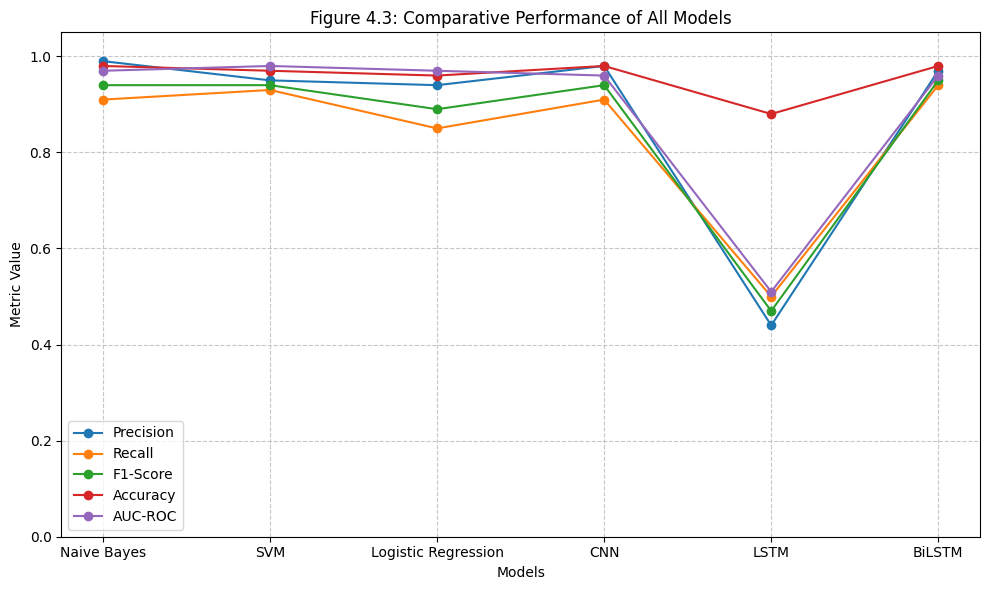

In [ ]:
import matplotlib.pyplot as plt

# Data
models_all = ['Naive Bayes', 'SVM', 'Logistic Regression', 'CNN', 'LSTM', 'BiLSTM']
precision_all = [0.99, 0.95, 0.94, 0.98, 0.44, 0.97]
recall_all = [0.91, 0.93, 0.85, 0.91, 0.50, 0.94]
f1_all = [0.94, 0.94, 0.89, 0.94, 0.47, 0.95]
accuracy_all = [0.98, 0.97, 0.96, 0.98, 0.88, 0.98]
auc_all = [0.97, 0.98, 0.97, 0.96, 0.51, 0.96]

# Plot
plt.figure(figsize=(10,6))
plt.plot(models_all, precision_all, marker='o', label='Precision')
plt.plot(models_all, recall_all, marker='o', label='Recall')
plt.plot(models_all, f1_all, marker='o', label='F1-Score')
plt.plot(models_all, accuracy_all, marker='o', label='Accuracy')
plt.plot(models_all, auc_all, marker='o', label='AUC-ROC')

# Formatting
plt.ylim(0, 1.05)
plt.ylabel('Metric Value')
plt.xlabel('Models')
plt.title('Figure 4.3: Comparative Performance of All Models')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower left')  # you can change position if needed

# Save & show
plt.tight_layout()
plt.savefig("figure4_3_comparative_line.png", dpi=300)
plt.show()


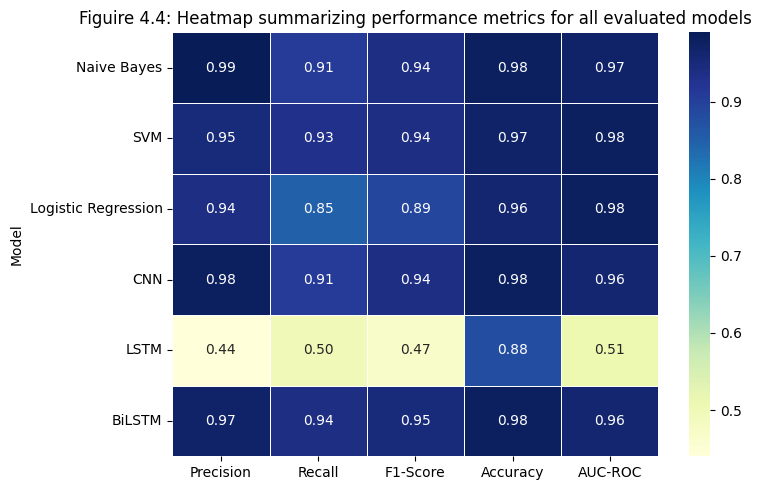

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data
data = {
    'Model': ['Naive Bayes', 'SVM', 'Logistic Regression', 'CNN', 'LSTM', 'BiLSTM'],
    'Precision': [0.99, 0.95, 0.94, 0.98, 0.44, 0.97],
    'Recall': [0.91, 0.93, 0.85, 0.91, 0.50, 0.94],
    'F1-Score': [0.94, 0.94, 0.89, 0.94, 0.47, 0.95],
    'Accuracy': [0.98, 0.97, 0.96, 0.98, 0.88, 0.98],
    'AUC-ROC': [0.97, 0.98, 0.98, 0.96, 0.51, 0.96]
}

# Convert to DataFrame
df = pd.DataFrame(data)
df.set_index('Model', inplace=True)

# Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)

plt.title("Figuire 4.4: Heatmap summarizing performance metrics for all evaluated models")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
from google.colab import files
files.download("figure4_3_comparative_heatmap.png")  # or heatmap/bar chart filename


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>